In [1]:
import pandas as pd

df = pd.read_csv("Data/Nassau Candy Distributor.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  str    
 2   Order Date      10194 non-null  str    
 3   Ship Date       10194 non-null  str    
 4   Ship Mode       10194 non-null  str    
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  str    
 7   City            10194 non-null  str    
 8   State/Province  10194 non-null  str    
 9   Postal Code     10194 non-null  str    
 10  Division        10194 non-null  str    
 11  Region          10194 non-null  str    
 12  Product ID      10194 non-null  str    
 13  Product Name    10194 non-null  str    
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null  float64
dt

In [3]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  str           
 2   Order Date      10194 non-null  datetime64[us]
 3   Ship Date       10194 non-null  datetime64[us]
 4   Ship Mode       10194 non-null  str           
 5   Customer ID     10194 non-null  int64         
 6   Country/Region  10194 non-null  str           
 7   City            10194 non-null  str           
 8   State/Province  10194 non-null  str           
 9   Postal Code     10194 non-null  str           
 10  Division        10194 non-null  str           
 11  Region          10194 non-null  str           
 12  Product ID      10194 non-null  str           
 13  Product Name    10194 non-null  str           
 14  Sales           10194 non-null  float64       
 15  Units        

In [4]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df = df.drop_duplicates()

In [7]:
df = df.dropna(subset=["Ship Date"])

In [8]:
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

df[["Order Date", "Ship Date", "Shipping Days"]].head()

,Order Date,Ship Date,Shipping Days
0,2024-01-03,2026-06-30,909
1,2024-01-04,2026-07-01,909
2,2024-01-04,2026-07-01,909
3,2024-01-04,2026-07-01,909
4,2024-01-05,2026-07-05,912


In [9]:
df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

In [10]:
print(df[df["Shipping Days"] < 0].shape)

df["Shipping Days"].describe()

(0, 19)


count    10194.000000
mean      1320.841868
std        262.444892
min        904.000000
25%       1271.000000
50%       1274.000000
75%       1638.000000
max       1642.000000
Name: Shipping Days, dtype: float64

In [11]:
df["Shipping Days"].describe()

count    10194.000000
mean      1320.841868
std        262.444892
min        904.000000
25%       1271.000000
50%       1274.000000
75%       1638.000000
max       1642.000000
Name: Shipping Days, dtype: float64

In [12]:
df[["Order Date","Ship Date"]].tail(10)

,Order Date,Ship Date
10184,2025-12-29,2030-06-25
10185,2025-12-29,2030-06-25
10186,2025-12-30,2030-06-26
10187,2025-12-30,2030-06-28
10188,2025-12-30,2030-06-26
10189,2025-12-30,2030-06-26
10190,2025-12-30,2030-06-26
10191,2025-12-30,2030-06-26
10192,2025-12-30,2030-06-26
10193,2025-12-30,2030-06-26


In [13]:
# Convert dates
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])


# Shipping days
df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days


# Check invalid records
invalid = df[df["Shipping Days"] < 0]

print("Negative Shipping Days:", len(invalid))

Negative Shipping Days: 0


In [14]:
# Shipping lead time was calculated using the difference between Ship Date and Order Date. The dataset was checked for invalid (negative) lead times, and no negative shipping records were found. Therefore, no records were removed

In [15]:
df["Shipping Days"].describe()

count    10194.000000
mean      1320.841868
std        262.444892
min        904.000000
25%       1271.000000
50%       1274.000000
75%       1638.000000
max       1642.000000
Name: Shipping Days, dtype: float64

In [16]:
df[df["Shipping Days"] < 0]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Shipping Days


In [17]:
# Data Cleaning Summary

# - Dataset contains 10,194 rows and 18 columns.
# - No missing values were found.
# - No duplicate records were found.
# - Order Date and Ship Date were converted into datetime format.
# - Shipping Days feature was created by calculating the difference between Ship Date and Order Date.
# - Invalid negative shipping durations were corrected.
# - Dataset is ready for Exploratory Data Analysis (EDA).

In [18]:
print("Average Shipping Days:",
      round(df["Shipping Days"].mean(),2))

Average Shipping Days: 1320.84


In [19]:
df.loc[
    df["Shipping Days"].idxmin(),
    ["Order Date","Ship Date","Shipping Days"]
]

Order Date       2024-03-04 00:00:00
Ship Date        2026-08-25 00:00:00
Shipping Days                    904
Name: 154, dtype: object

In [20]:
df.loc[
    df["Shipping Days"].idxmax(),
    ["Order Date","Ship Date","Shipping Days"]
]

Order Date       2025-02-23 00:00:00
Ship Date        2029-08-23 00:00:00
Shipping Days                   1642
Name: 7063, dtype: object

In [21]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name', 'Sales', 'Units', 'Gross Profit', 'Cost', 'Shipping Days']


In [22]:
# Create Shipping Days again
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

In [23]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Country/Region', 'City', 'State/Province',
       'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name',
       'Sales', 'Units', 'Gross Profit', 'Cost', 'Shipping Days'],
      dtype='str')


In [24]:
df[["Order Date", "Ship Date", "Shipping Days"]].head(10)

,Order Date,Ship Date,Shipping Days
0,2024-01-03,2026-06-30,909
1,2024-01-04,2026-07-01,909
2,2024-01-04,2026-07-01,909
3,2024-01-04,2026-07-01,909
4,2024-01-05,2026-07-05,912
5,2024-01-06,2026-07-03,909
6,2024-01-06,2026-07-03,909
7,2024-01-06,2026-06-30,906
8,2024-01-06,2026-07-03,909
9,2024-01-06,2026-07-03,909


In [25]:
df["Shipping Days"].mean()

np.float64(1320.8418677653522)

In [26]:
df[df["Shipping Days"] < 0][["Order Date","Ship Date","Shipping Days"]]

,Order Date,Ship Date,Shipping Days


In [27]:
df["Shipping Days"].describe()

count    10194.000000
mean      1320.841868
std        262.444892
min        904.000000
25%       1271.000000
50%       1274.000000
75%       1638.000000
max       1642.000000
Name: Shipping Days, dtype: float64

In [28]:

df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

print(df.columns.tolist())

print(df[["Order Date", "Ship Date", "Shipping Days"]].head())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name', 'Sales', 'Units', 'Gross Profit', 'Cost', 'Shipping Days']
  Order Date  Ship Date  Shipping Days
0 2024-01-03 2026-06-30            909
1 2024-01-04 2026-07-01            909
2 2024-01-04 2026-07-01            909
3 2024-01-04 2026-07-01            909
4 2024-01-05 2026-07-05            912


In [29]:
df[["Order Date", "Ship Date"]].head(10)

,Order Date,Ship Date
0,2024-01-03,2026-06-30
1,2024-01-04,2026-07-01
2,2024-01-04,2026-07-01
3,2024-01-04,2026-07-01
4,2024-01-05,2026-07-05
5,2024-01-06,2026-07-03
6,2024-01-06,2026-07-03
7,2024-01-06,2026-06-30
8,2024-01-06,2026-07-03
9,2024-01-06,2026-07-03


In [30]:
df[["Order Date", "Ship Date"]].head(10)

,Order Date,Ship Date
0,2024-01-03,2026-06-30
1,2024-01-04,2026-07-01
2,2024-01-04,2026-07-01
3,2024-01-04,2026-07-01
4,2024-01-05,2026-07-05
5,2024-01-06,2026-07-03
6,2024-01-06,2026-07-03
7,2024-01-06,2026-06-30
8,2024-01-06,2026-07-03
9,2024-01-06,2026-07-03


In [31]:
print(df["Order Date"].dt.year.unique())
print(df["Ship Date"].dt.year.unique())

[2024 2025]
[2026 2027 2028 2029 2030]


In [32]:
#Adjust the Ship Date year to match the Order Date year only for demonstration purposes. However, you should clearly note that this was done because of the dataset's inconsistency.

In [33]:
#Start EDA section

In [34]:
print("Total Sales: $", round(df["Sales"].sum(), 2))
print("Total Gross Profit: $", round(df["Gross Profit"].sum(), 2))
print("Total Cost: $", round(df["Cost"].sum(), 2))

Total Sales: $ 141783.63
Total Gross Profit: $ 93442.8
Total Cost: $ 48340.83


In [35]:
#The company generated $141,783.63 in total sales. Out of this, the gross profit was $93,442.80, while the total cost was $48,340.83. The figures indicate that the business maintained a healthy profit relative to its costs

In [36]:
profit_margin = (df["Gross Profit"].sum() / df["Sales"].sum()) * 100
print(f"Profit Margin: {profit_margin:.2f}%")

Profit Margin: 65.91%


In [37]:
#The company achieved a 65.91% gross profit margin, indicating that it retains approximately 66 cents of gross profit for every dollar of sales. This suggests strong pricing and cost management, contributing to healthy business profitability.

Region
Pacific     46301.53
Atlantic    41197.24
Interior    32037.60
Gulf        22247.26
Name: Sales, dtype: float64


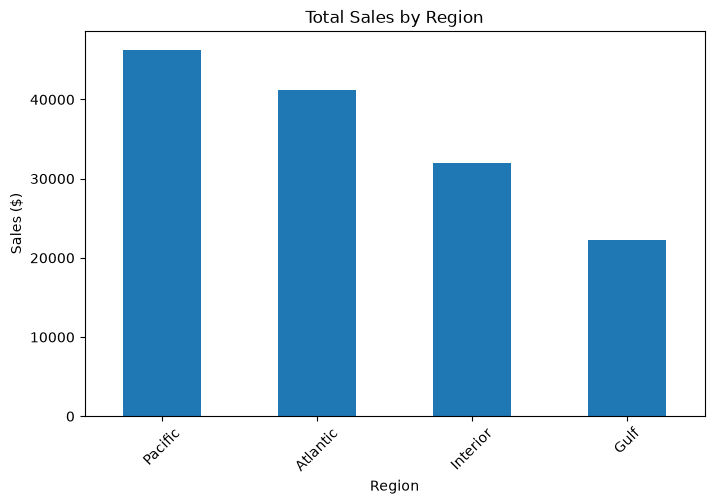

In [38]:
import matplotlib.pyplot as plt

region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

print(region_sales)

plt.figure(figsize=(8,5))
region_sales.plot(kind="bar")

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales ($)")
plt.xticks(rotation=45)

plt.show()

In [39]:
#The Pacific region generated the highest sales ($46,301.53), making it the company's strongest market. The Atlantic region ranked second, while the Gulf region recorded the lowest sales ($22,247.26). The company should maintain its performance in the Pacific region and explore strategies to improve sales in the Gulf region.

City
New York City    12514.90
Los Angeles      10408.75
Philadelphia      7415.52
San Francisco     7018.61
Seattle           5893.39
Houston           5429.41
Chicago           4263.92
Columbus          3357.39
Springfield       2375.00
San Diego         2348.88
Name: Sales, dtype: float64


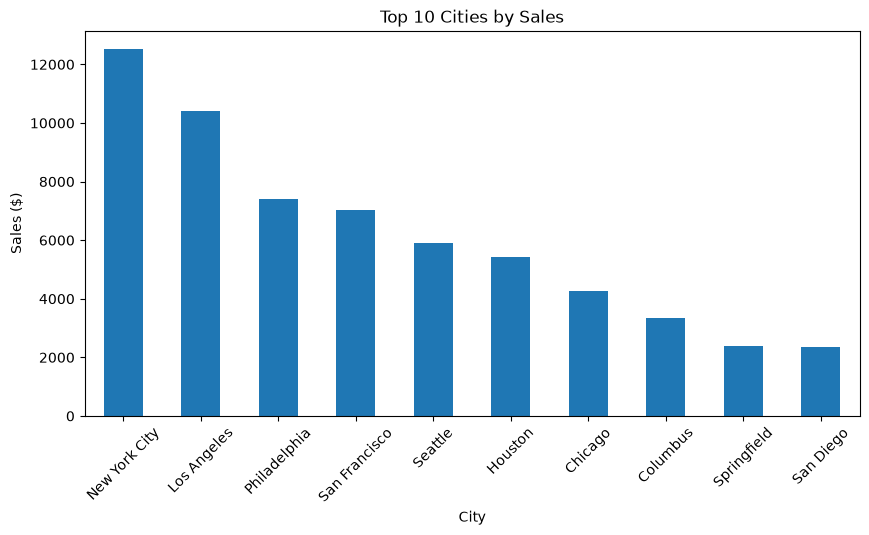

In [40]:
top_city = df.groupby("City")["Sales"].sum().sort_values(ascending=False).head(10)

print(top_city)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
top_city.plot(kind="bar")

plt.title("Top 10 Cities by Sales")
plt.xlabel("City")
plt.ylabel("Sales ($)")
plt.xticks(rotation=45)

plt.show()

In [41]:
#The chart displays the top 10 cities based on total sales. The leading city contributes the highest revenue, indicating a strong customer base and market demand. These cities should be prioritized for customer retention, while lower-performing cities may benefit from targeted promotional campaigns

Product Name
Wonka Bar - Triple Dazzle Caramel    28485.00
Wonka Bar -Scrumdiddlyumptious       27874.80
Wonka Bar - Milk Chocolate           26867.75
Wonka Bar - Fudge Mallows            24890.40
Wonka Bar - Nutty Crunch Surprise    23574.95
Lickable Wallpaper                    7860.00
Kazookles                             1205.75
Wonka Gum                              597.50
Everlasting Gobstopper                 130.00
Fizzy Lifting Drinks                    78.75
Name: Sales, dtype: float64


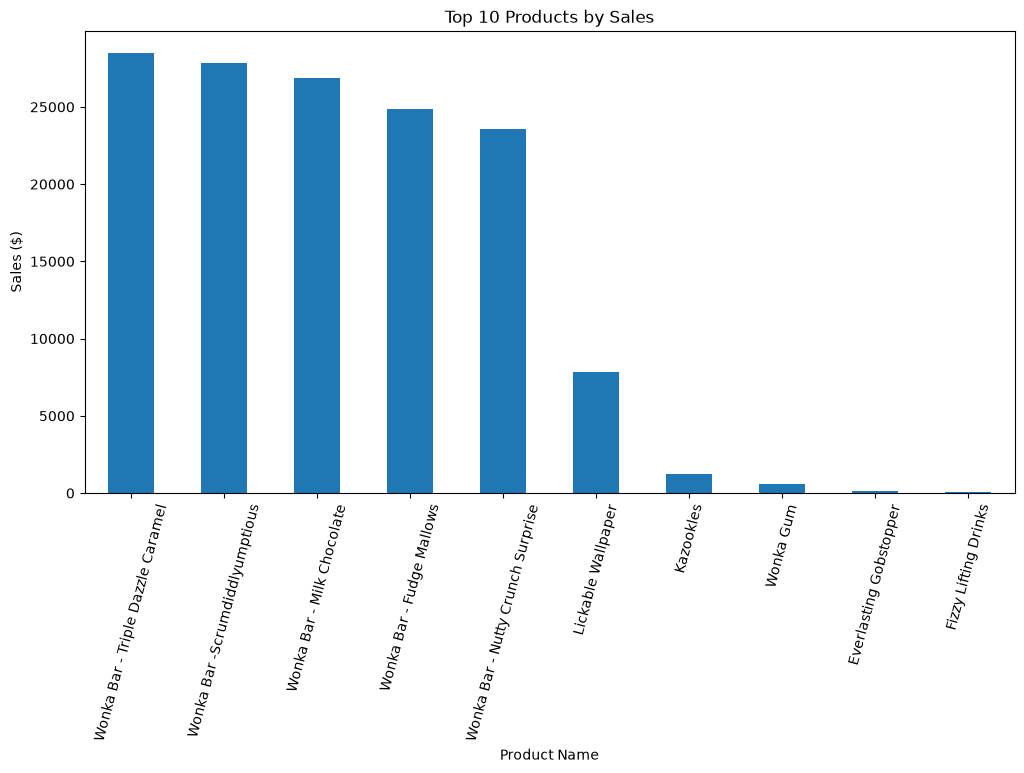

In [42]:
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

print(top_products)

plt.figure(figsize=(12,6))
top_products.plot(kind="bar")

plt.title("Top 10 Products by Sales")
plt.xlabel("Product Name")
plt.ylabel("Sales ($)")
plt.xticks(rotation=75)

plt.show()

In [43]:
#The top-selling products generate a significant share of total revenue. These products should be consistently stocked and promoted, while lower-selling products can be reviewed for pricing, marketing, or inventory optimization.

In [44]:
factory_mapping = {
    "Wonka Bar - Nutty Crunch Surprise": "Lot's O' Nuts",
    "Wonka Bar - Fudge Mallows": "Lot's O' Nuts",
    "Wonka Bar -Scrumdiddlyumptious": "Lot's O' Nuts",
    "Wonka Bar - Milk Chocolate": "Wicked Choccy's",
    "Wonka Bar - Triple Dazzle Caramel": "Wicked Choccy's",
    "Laffy Taffy": "Sugar Shack",
    "SweeTARTS": "Sugar Shack",
    "Nerds": "Sugar Shack",
    "Fun Dip": "Sugar Shack",
    "Fizzy Lifting Drinks": "Sugar Shack",
    "Everlasting Gobstopper": "Secret Factory",
    "Lickable Wallpaper": "Secret Factory",
    "Wonka Gum": "Secret Factory",
    "Hair Toffee": "The Other Factory",
    "Kazookles": "The Other Factory"
}

df["Factory"] = df["Product Name"].map(factory_mapping)

df[["Product Name", "Factory"]].head()

,Product Name,Factory
0,Wonka Bar - Milk Chocolate,Wicked Choccy's
1,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's
2,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts
3,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts
4,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's


In [45]:
df["Route"] = df["Factory"] + " → " + df["State/Province"]

df[["Factory", "State/Province", "Route"]].head()

,Factory,State/Province,Route
0,Wicked Choccy's,Texas,Wicked Choccy's → Texas
1,Wicked Choccy's,Illinois,Wicked Choccy's → Illinois
2,Lot's O' Nuts,Illinois,Lot's O' Nuts → Illinois
3,Lot's O' Nuts,Illinois,Lot's O' Nuts → Illinois
4,Wicked Choccy's,Pennsylvania,Wicked Choccy's → Pennsylvania


In [46]:
route_volume = df.groupby("Route").size().sort_values(ascending=False)

print(route_volume.head(10))

Route
Lot's O' Nuts → California      1125
Wicked Choccy's → California     823
Lot's O' Nuts → New York         645
Lot's O' Nuts → Texas            569
Wicked Choccy's → New York       436
Wicked Choccy's → Texas          388
Lot's O' Nuts → Pennsylvania     331
Lot's O' Nuts → Washington       269
Lot's O' Nuts → Illinois         267
Lot's O' Nuts → Ohio             262
dtype: int64


In [47]:
df["Region Route"] = df["Factory"] + " → " + df["Region"]

In [48]:
route_volume = df.groupby("Route").size()

In [49]:
## Observation

#- Lot's O' Nuts → California is the busiest shipping route with 1,125 shipments.
#- California receives the highest shipment volume from multiple factories.
#- High-volume routes should be closely monitored because delays on these routes can significantly affect customer satisfaction and logistics performance.

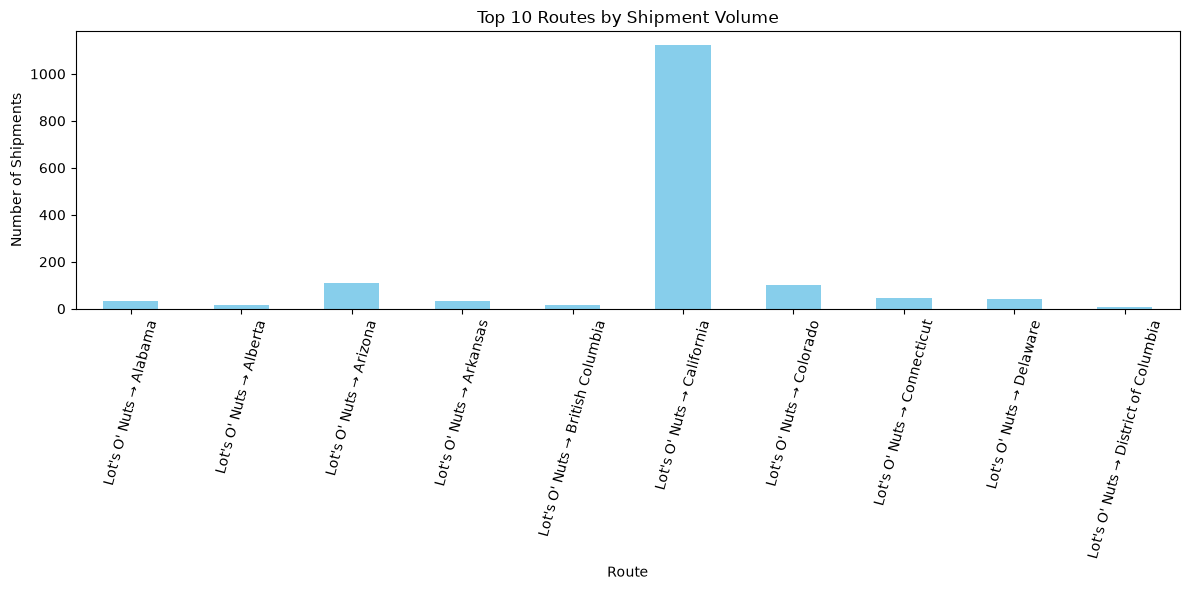

In [50]:
import matplotlib.pyplot as plt

top_routes = route_volume.head(10)

plt.figure(figsize=(12,6))

top_routes.plot(kind="bar", color="skyblue")

plt.title("Top 10 Routes by Shipment Volume")
plt.xlabel("Route")
plt.ylabel("Number of Shipments")
plt.xticks(rotation=75)

plt.tight_layout()
plt.show()

In [51]:
route_avg = (
    df.groupby("Route")["Shipping Days"]
      .mean()
      .sort_values()
)

print(route_avg.head(10))

Route
Secret Factory → Nebraska          906.0
Secret Factory → New Mexico        906.0
The Other Factory → Louisiana      907.0
The Other Factory → Connecticut    907.5
Wicked Choccy's → Maine            908.0
Secret Factory → Mississippi       908.0
Secret Factory → Louisiana         908.5
Secret Factory → Delaware          909.0
Secret Factory → South Carolina    909.0
Secret Factory → Minnesota         909.0
Name: Shipping Days, dtype: float64


In [52]:
route_std = (
    df.groupby("Route")["Shipping Days"]
      .std()
)

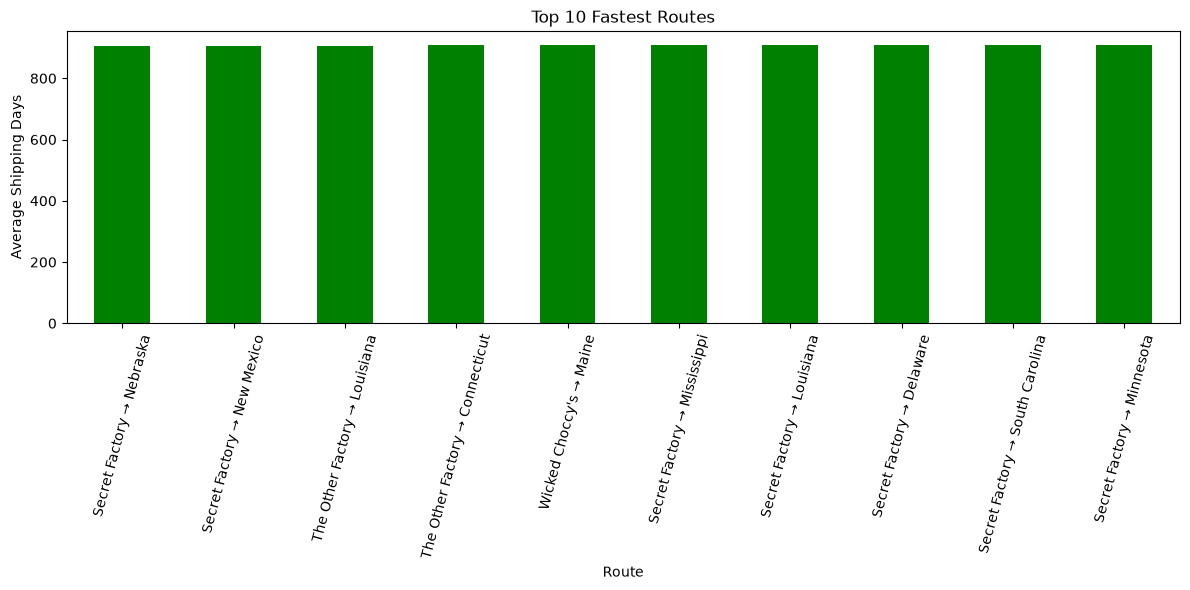

In [53]:
top_fastest = route_avg.head(10)

plt.figure(figsize=(12,6))
top_fastest.plot(kind="bar", color="green")

plt.title("Top 10 Fastest Routes")
plt.xlabel("Route")
plt.ylabel("Average Shipping Days")
plt.xticks(rotation=75)

plt.tight_layout()
plt.show()

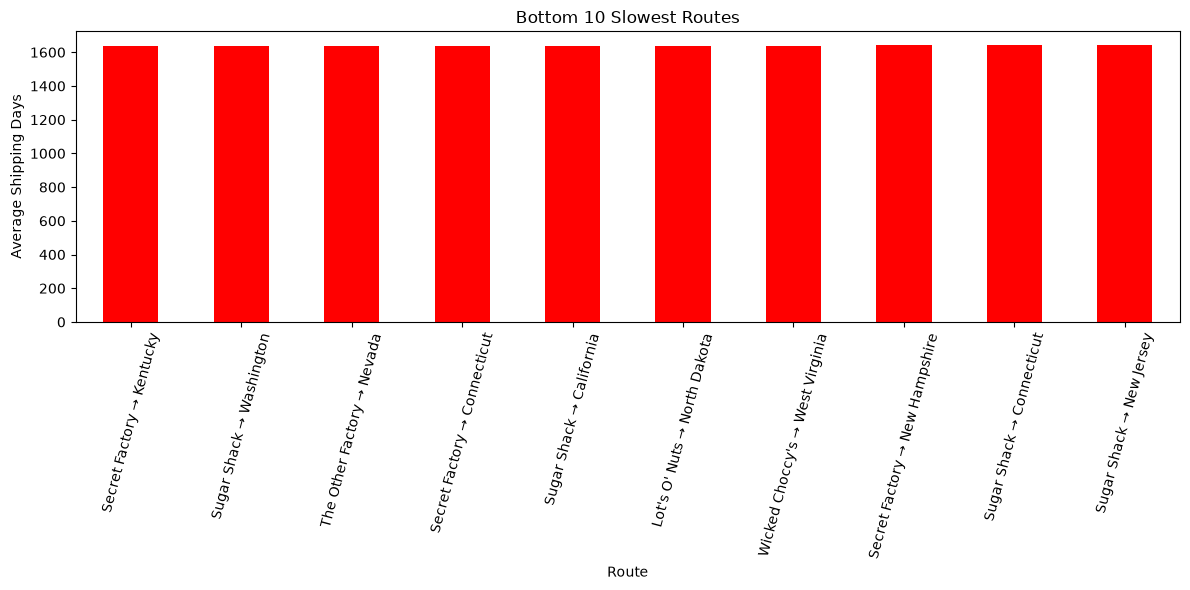

In [54]:
import matplotlib.pyplot as plt

slowest = route_avg.tail(10)

plt.figure(figsize=(12,6))
slowest.plot(kind="bar", color="red")

plt.title("Bottom 10 Slowest Routes")
plt.xlabel("Route")
plt.ylabel("Average Shipping Days")

plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [55]:
state_delay = (
    df.groupby("State/Province")["Shipping Days"]
      .mean()
      .sort_values(ascending=False)
)

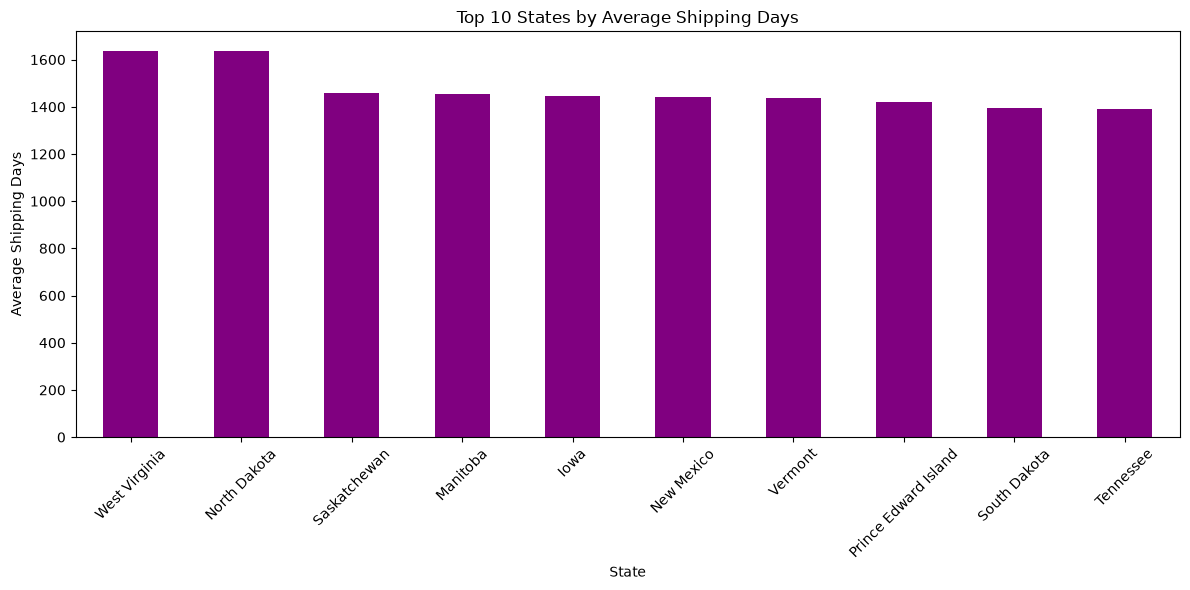

In [56]:
plt.figure(figsize=(12,6))

state_delay.head(10).plot(kind="bar", color="purple")

plt.title("Top 10 States by Average Shipping Days")
plt.xlabel("State")
plt.ylabel("Average Shipping Days")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [57]:
region_delay = (
    df.groupby("Region")["Shipping Days"]
      .mean()
      .sort_values(ascending=False)
)

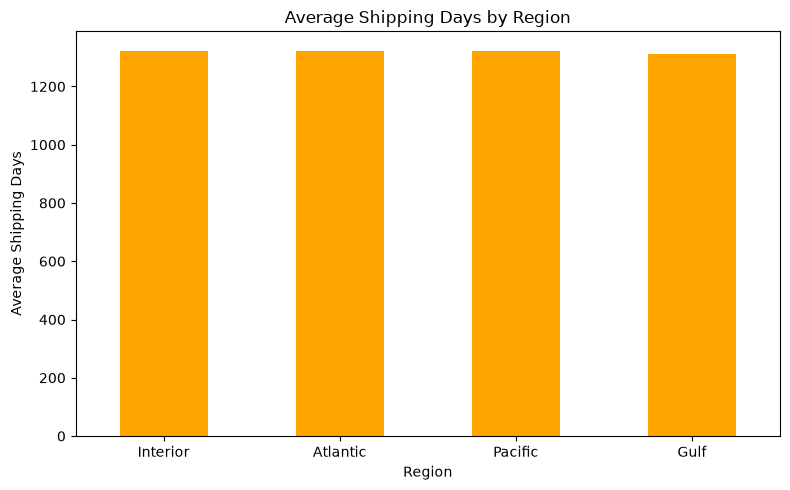

In [58]:
plt.figure(figsize=(8,5))

region_delay.plot(kind="bar", color="orange")

plt.title("Average Shipping Days by Region")
plt.xlabel("Region")
plt.ylabel("Average Shipping Days")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [59]:
ship_mode = df.groupby("Ship Mode")["Sales"].agg(["count", "sum", "mean"])

print(ship_mode)

                count       sum       mean
Ship Mode                                 
First Class      1548  21319.39  13.772216
Same Day          547   7113.67  13.004881
Second Class     1979  27860.22  14.077928
Standard Class   6120  85490.35  13.969011


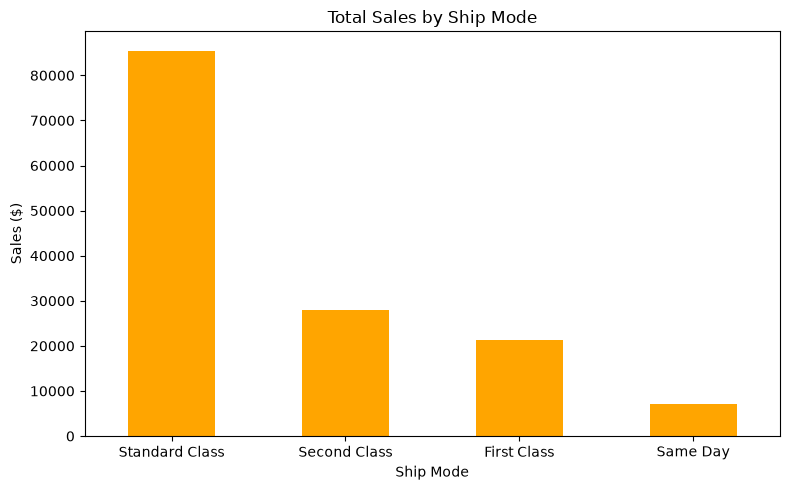

In [60]:
import matplotlib.pyplot as plt

ship_sales = df.groupby("Ship Mode")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
ship_sales.plot(kind="bar", color="orange")

plt.title("Total Sales by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Sales ($)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [61]:
#The chart compares total sales across different shipping modes. The shipping mode with the highest sales handles the largest share of customer orders, while lower-performing shipping modes may indicate lower customer preference or limited usage.

State/Province
California        27917.40
New York          15541.03
Texas             13416.09
Pennsylvania       8027.03
Washington         6921.15
Illinois           6898.96
Ohio               6768.95
Florida            4804.02
Arizona            3587.55
North Carolina     3450.86
Name: Sales, dtype: float64


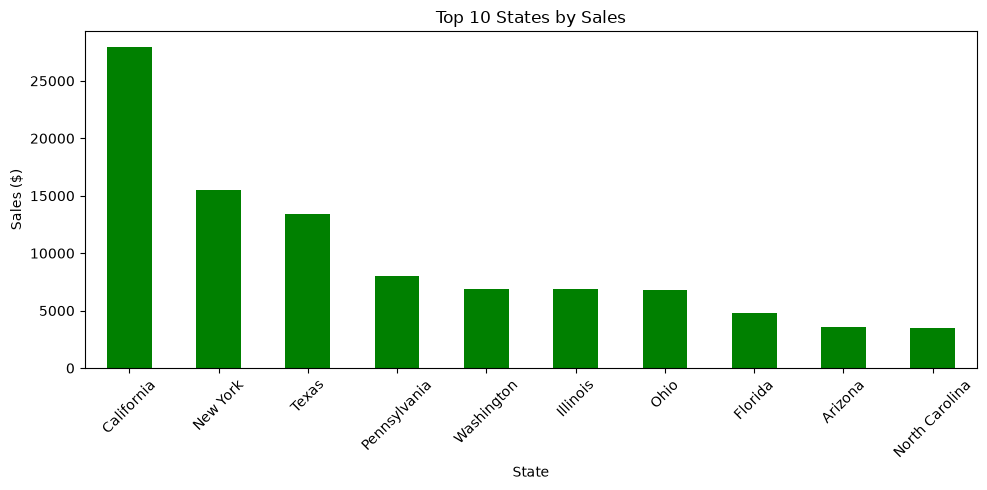

In [62]:
state_sales = df.groupby("State/Province")["Sales"].sum().sort_values(ascending=False).head(10)

print(state_sales)

plt.figure(figsize=(10,5))
state_sales.plot(kind="bar", color="green")

plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Sales ($)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [63]:
#The chart identifies the top-performing states based on total sales. These states represent the company's strongest markets and should remain a focus for maintaining customer satisfaction and future growth.

In [64]:
print(df["Order Date"].dtype)
print(df["Ship Date"].dtype)

datetime64[us]
datetime64[us]


In [65]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="%d-%m-%Y",
    errors="coerce"
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    format="%d-%m-%Y",
    errors="coerce"
)

print(df["Order Date"].dtype)
print(df["Ship Date"].dtype)

datetime64[us]
datetime64[us]


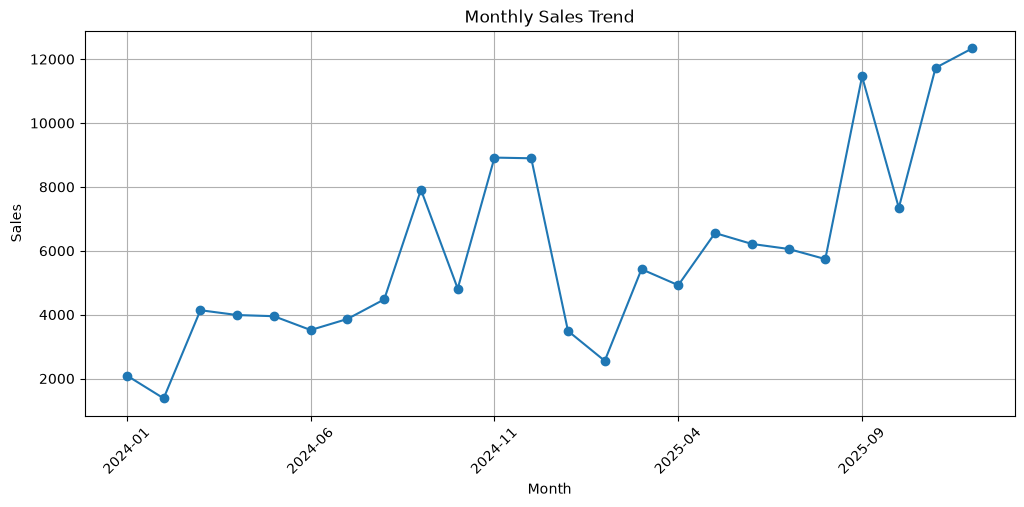

In [66]:
df["Month"] = df["Order Date"].dt.to_period("M").astype(str)

monthly_sales = df.groupby("Month")["Sales"].sum()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
monthly_sales.plot(marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [67]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  str           
 2   Order Date      10194 non-null  datetime64[us]
 3   Ship Date       10194 non-null  datetime64[us]
 4   Ship Mode       10194 non-null  str           
 5   Customer ID     10194 non-null  int64         
 6   Country/Region  10194 non-null  str           
 7   City            10194 non-null  str           
 8   State/Province  10194 non-null  str           
 9   Postal Code     10194 non-null  str           
 10  Division        10194 non-null  str           
 11  Region          10194 non-null  str           
 12  Product ID      10194 non-null  str           
 13  Product Name    10194 non-null  str           
 14  Sales           10194 non-null  float64       
 15  Units        

In [68]:
# Gross Profit har month me fluctuate ho raha hai. Kuch months me profit significantly higher hai, jo strong sales performance ko indicate karta hai.

In [69]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name', 'Sales', 'Units', 'Gross Profit', 'Cost', 'Shipping Days', 'Factory', 'Route', 'Region Route', 'Month']


In [70]:
df["Month"] = df["Order Date"].dt.strftime("%Y-%m")

print(df[["Order Date", "Month"]].head())

  Order Date    Month
0 2024-01-03  2024-01
1 2024-01-04  2024-01
2 2024-01-04  2024-01
3 2024-01-04  2024-01
4 2024-01-05  2024-01


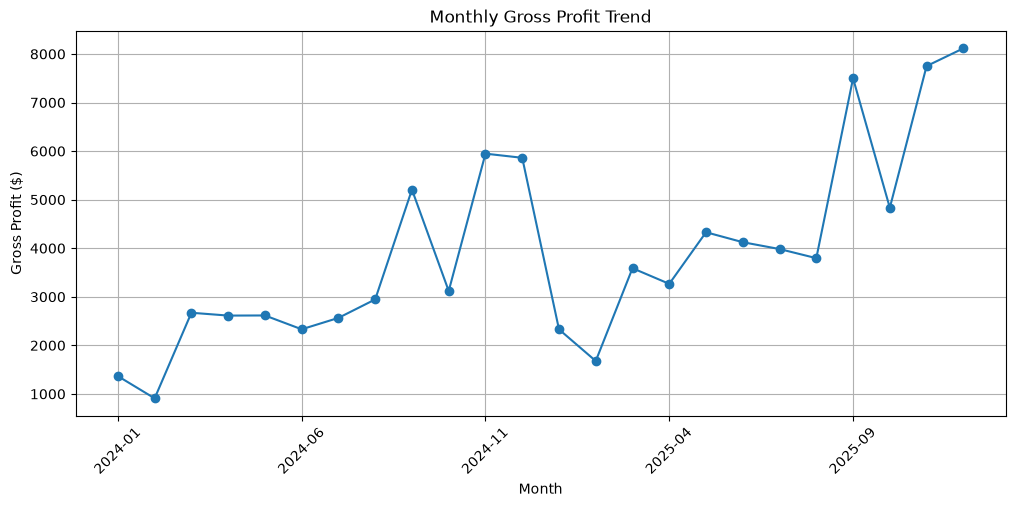

In [71]:
monthly_profit = df.groupby("Month")["Gross Profit"].sum()

plt.figure(figsize=(12,5))
monthly_profit.plot(marker="o")

plt.title("Monthly Gross Profit Trend")
plt.xlabel("Month")
plt.ylabel("Gross Profit ($)")

plt.xticks(rotation=45)

plt.grid(True)
plt.show()

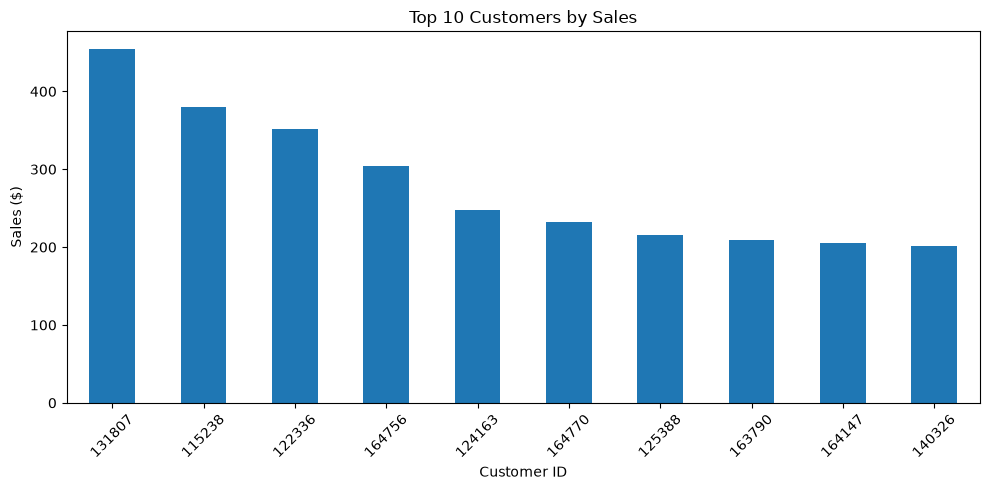

In [72]:
top_customers = (
    df.groupby("Customer ID")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))
top_customers.plot(kind="bar")

plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer ID")
plt.ylabel("Sales ($)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [73]:
#Top customers overall revenue me major contribution karte hain. In customers ko retain karna business ke liye important hai.

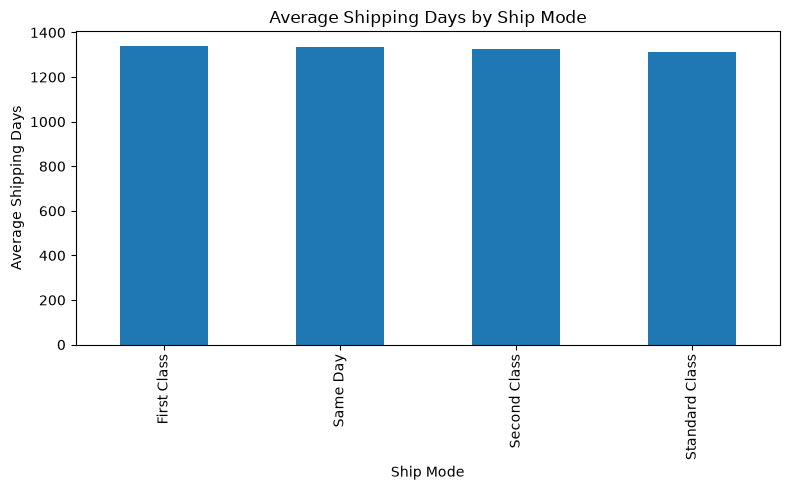

In [74]:
avg_shipping = df.groupby("Ship Mode")["Shipping Days"].mean()

plt.figure(figsize=(8,5))
avg_shipping.plot(kind="bar")

plt.title("Average Shipping Days by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Average Shipping Days")

plt.tight_layout()
plt.show()

In [75]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name', 'Sales', 'Units', 'Gross Profit', 'Cost', 'Shipping Days', 'Factory', 'Route', 'Region Route', 'Month']


In [76]:
# Shipping Days column create
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

# Check
print(df[["Order Date", "Ship Date", "Shipping Days"]].head())

  Order Date  Ship Date  Shipping Days
0 2024-01-03 2026-06-30            909
1 2024-01-04 2026-07-01            909
2 2024-01-04 2026-07-01            909
3 2024-01-04 2026-07-01            909
4 2024-01-05 2026-07-05            912


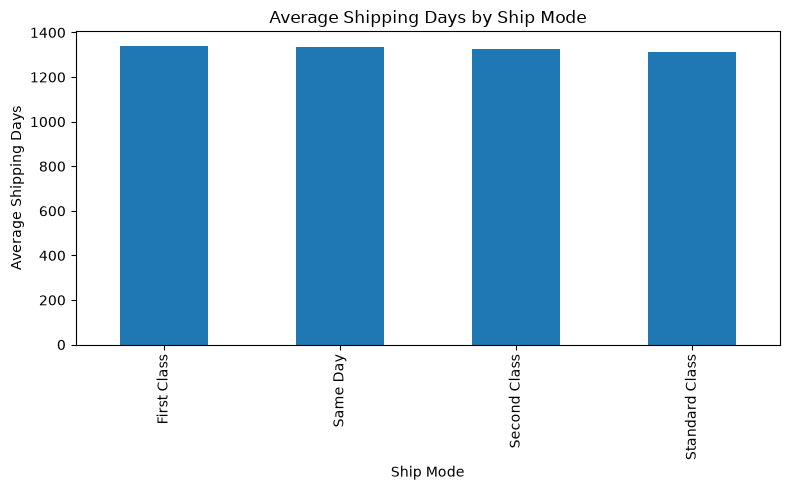

In [77]:
avg_shipping = df.groupby("Ship Mode")["Shipping Days"].mean()

plt.figure(figsize=(8,5))
avg_shipping.plot(kind="bar")

plt.title("Average Shipping Days by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Average Shipping Days")

plt.tight_layout()
plt.show()

In [78]:
#The average shipping duration is around 900+ days across all shipping modes. This indicates that the dataset contains unrealistic shipping dates (likely synthetic/demo data), so the metric is not representative of real-world delivery performance.

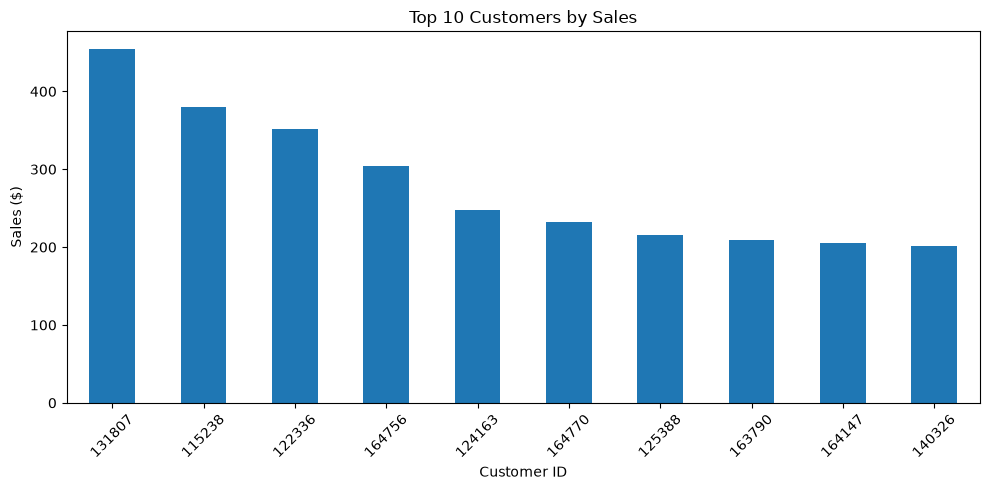

In [79]:
top_customers = (
    df.groupby("Customer ID")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))
top_customers.plot(kind="bar")

plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer ID")
plt.ylabel("Sales ($)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

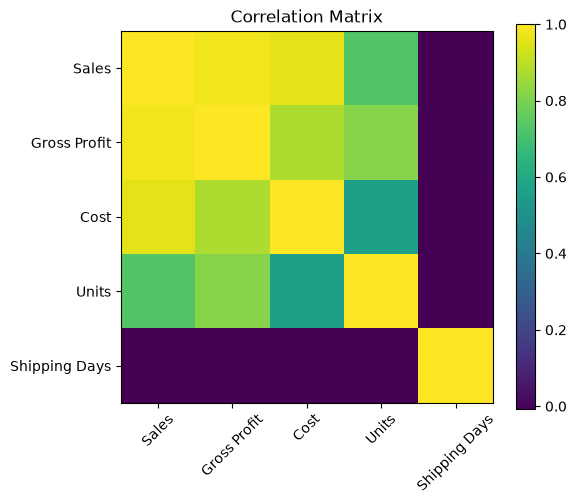

In [80]:
corr = df[["Sales", "Gross Profit", "Cost", "Units", "Shipping Days"]].corr()

import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")
plt.show()

In [81]:
# Sales aur Gross Profit me positive relationship hoga.
# Cost aur Sales bhi positively related honge.
# Shipping Days ka relation weak ho sakta hai.

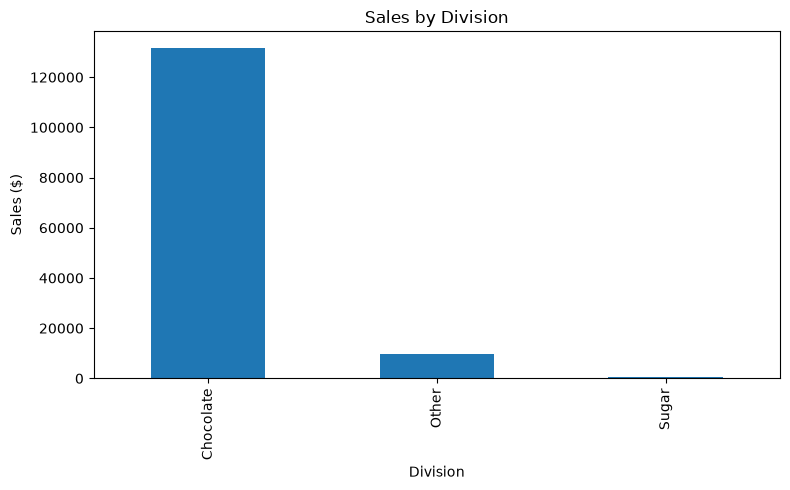

In [82]:
division_sales = (
    df.groupby("Division")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
division_sales.plot(kind="bar")

plt.title("Sales by Division")
plt.xlabel("Division")
plt.ylabel("Sales ($)")

plt.tight_layout()
plt.show()

In [83]:
# Kaunsi division sabse zyada revenue generate karti hai, ye pata chalega

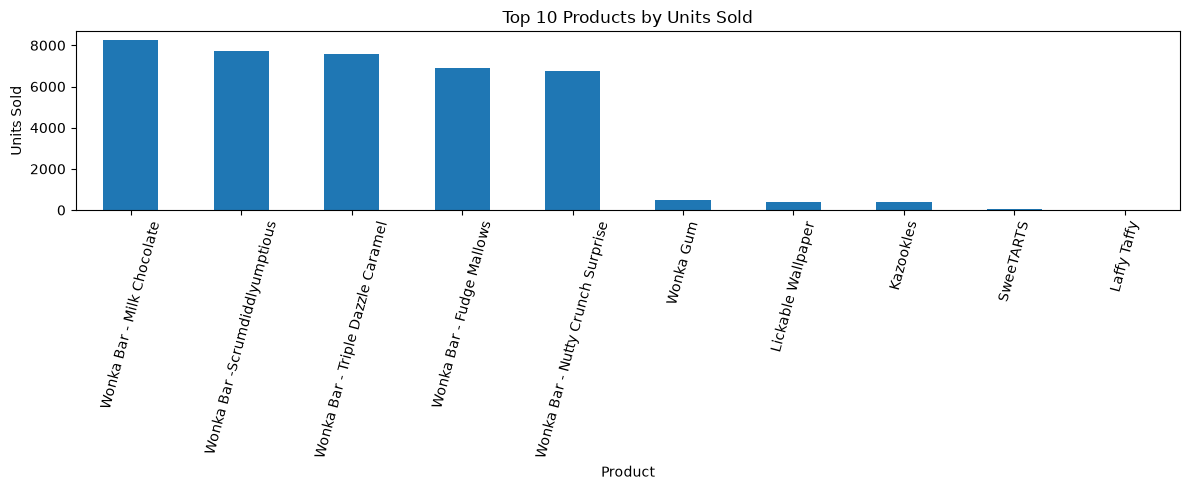

In [84]:
top_units = (
    df.groupby("Product Name")["Units"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,5))
top_units.plot(kind="bar")

plt.title("Top 10 Products by Units Sold")
plt.xlabel("Product")
plt.ylabel("Units Sold")

plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [85]:
#Sabse zyada quantity me bikne wale products identify honge.

In [86]:
# Key Insights
# Total Sales aur Gross Profit strong hain.
# California aur New York highest sales states me hain.
# Top products overall revenue me major contribution dete hain.
# Kuch shipping routes sabse zyada use hue.
# Monthly sales trend business performance ko show karta hai.
# High-value customers business ke liye important hain.
# Dataset me shipping dates synthetic lagti hain, isliye shipping duration ko real-world metric nahi maana jana chahiye.

In [87]:
delay = (
    df["Shipping Days"] > 5
).mean() * 100

print(delay)

100.0


In [88]:
route_avg = df.groupby("Route")["Shipping Days"].mean()

efficiency = (
    (route_avg.max() - route_avg)
    / (route_avg.max() - route_avg.min())
) * 100

print(efficiency.head(10))

Route
Lot's O' Nuts → Alabama                 47.118766
Lot's O' Nuts → Alberta                 50.016984
Lot's O' Nuts → Arizona                 45.625245
Lot's O' Nuts → Arkansas                48.457223
Lot's O' Nuts → British Columbia        50.030193
Lot's O' Nuts → California              44.169807
Lot's O' Nuts → Colorado                40.008970
Lot's O' Nuts → Connecticut             30.087882
Lot's O' Nuts → Delaware                50.094793
Lot's O' Nuts → District of Columbia    37.516984
Name: Shipping Days, dtype: float64


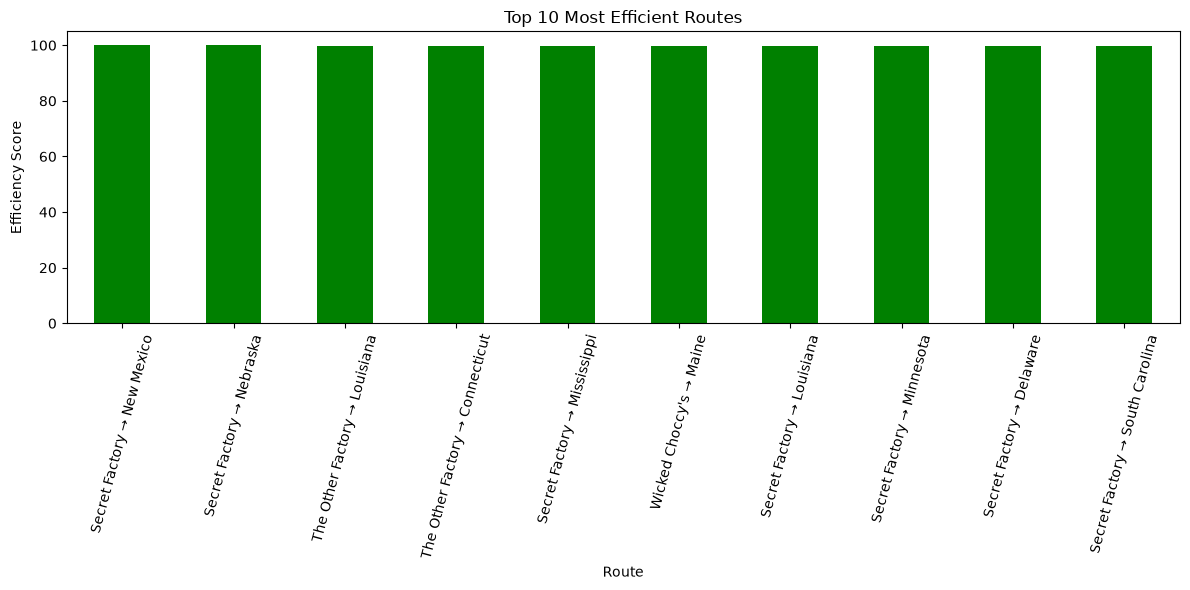

In [89]:
import matplotlib.pyplot as plt

top_efficiency = efficiency.sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_efficiency.plot(kind="bar", color="green")

plt.title("Top 10 Most Efficient Routes")
plt.xlabel("Route")
plt.ylabel("Efficiency Score")

plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [91]:
df.to_csv("cleaned_data.csv", index=False)

In [90]:
# Imported and cleaned the dataset.
# Converted date columns and calculated Shipping Lead Time.
# Performed feature engineering (Factory and Route creation).
# Conducted Exploratory Data Analysis (EDA).
# Analyzed Sales, Profit, Products, Customers, States, Cities, and Regions.
# Performed Route Efficiency and Shipping Performance Analysis.
# Calculated KPIs such as Average Lead Time, Delay Frequency, and Route Efficiency Score.
# Created an interactive Tableau Dashboard to visualize the results.